In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
from matplotlib import pyplot as plt

In [2]:
orig_cfa_res = pd.read_csv('../data/cfa/orig_cfa_res.csv')

In [3]:
orig_cfa_res

,pair,pconfig,pthresholds,pmetric,pscalar,pstrict,scale
0,V_GP,0.000,NaN,NaN,NaN,NaN,anhedonic_depression
1,V_EN,0.956,0.144,0.010,NaN,NaN,anhedonic_depression
2,GP_EN,0.144,0.021,NaN,NaN,NaN,anhedonic_depression
3,V_GP,0.210,0.002,NaN,NaN,NaN,anxious_worry
4,V_EN,0.961,0.192,0.001,NaN,NaN,anxious_worry
5,GP_EN,0.099,0.422,0.000,NaN,NaN,anxious_worry
6,V_GP,0.939,0.214,0.004,NaN,NaN,appetite_gain
7,V_EN,0.871,0.409,0.123,0.000,NaN,appetite_gain
8,GP_EN,0.738,0.842,0.110,0.006,NaN,appetite_gain
9,V_GP,0.429,0.021,NaN,NaN,NaN,appetite_loss


In [4]:
palette = sns.color_palette('Pastel1', 8)

In [5]:
palette

[(0.984313725490196, 0.7058823529411765, 0.6823529411764706),
 (0.7019607843137254, 0.803921568627451, 0.8901960784313725),
 (0.8, 0.9215686274509803, 0.7725490196078432),
 (0.8705882352941177, 0.796078431372549, 0.8941176470588236),
 (0.996078431372549, 0.8509803921568627, 0.6509803921568628),
 (1.0, 1.0, 0.8),
 (0.8980392156862745, 0.8470588235294118, 0.7411764705882353),
 (0.9921568627450981, 0.8549019607843137, 0.9254901960784314)]

In [6]:
# six categories now: Fails Configural / Configural / Thresholds / Metric / Scalar / Strict
colors = [palette[0], palette[5], palette[6], palette[4], palette[1], palette[2]]

In [7]:
# Highest invariance level PASSED per scale x pair, computed explicitly
# from the p-values. (The old version counted null columns, which broke
# when the measEq pipeline added the thresholds level, and it credited the
# last level as passed merely for having been tested.)
# Levels are gated: a level was only tested if the one below passed, so a
# level counts as passed iff its p >= .05. Configural is special: it can
# also pass via the secondary fit criteria (p < .05 but the ladder
# continued), which shows up as a non-null thresholds p.
level_cols = ['pconfig', 'pthresholds', 'pmetric', 'pscalar', 'pstrict']


def highest_level_passed(row):
    config_passed = (
        (pd.notna(row['pconfig']) and row['pconfig'] >= 0.05)
        or pd.notna(row['pthresholds'])  # secondary-criteria pass
    )
    if not config_passed:
        return 0  # fails configural
    level = 1
    for col in level_cols[1:]:
        if pd.notna(row[col]) and row[col] >= 0.05:
            level += 1
        else:
            break
    return level


orig_cfa_res['level_passed'] = orig_cfa_res.apply(highest_level_passed, axis=1)
to_plot = orig_cfa_res.pivot(index='scale', columns='pair', values='level_passed')
to_plot = to_plot.reset_index()
to_plot['scale'] = to_plot.scale.str.replace('_', ' ').str.title()
to_plot['scale'] = to_plot.scale.replace('Shame Guilt', 'Shame/Guilt')
to_plot['scale'] = to_plot.scale.replace('Well Being', 'Well-Being')
to_plot = to_plot.rename(columns={'scale':'Scale'})
to_plot = to_plot.set_index('Scale')
to_plot.columns.name = 'Data Pairs'
to_plot = to_plot.rename(columns={'GP_EN':'GenPop\nEnriched', 'V_EN':'OG Valid\nEnriched', 'V_GP':'OG Valid\nGenPop'})

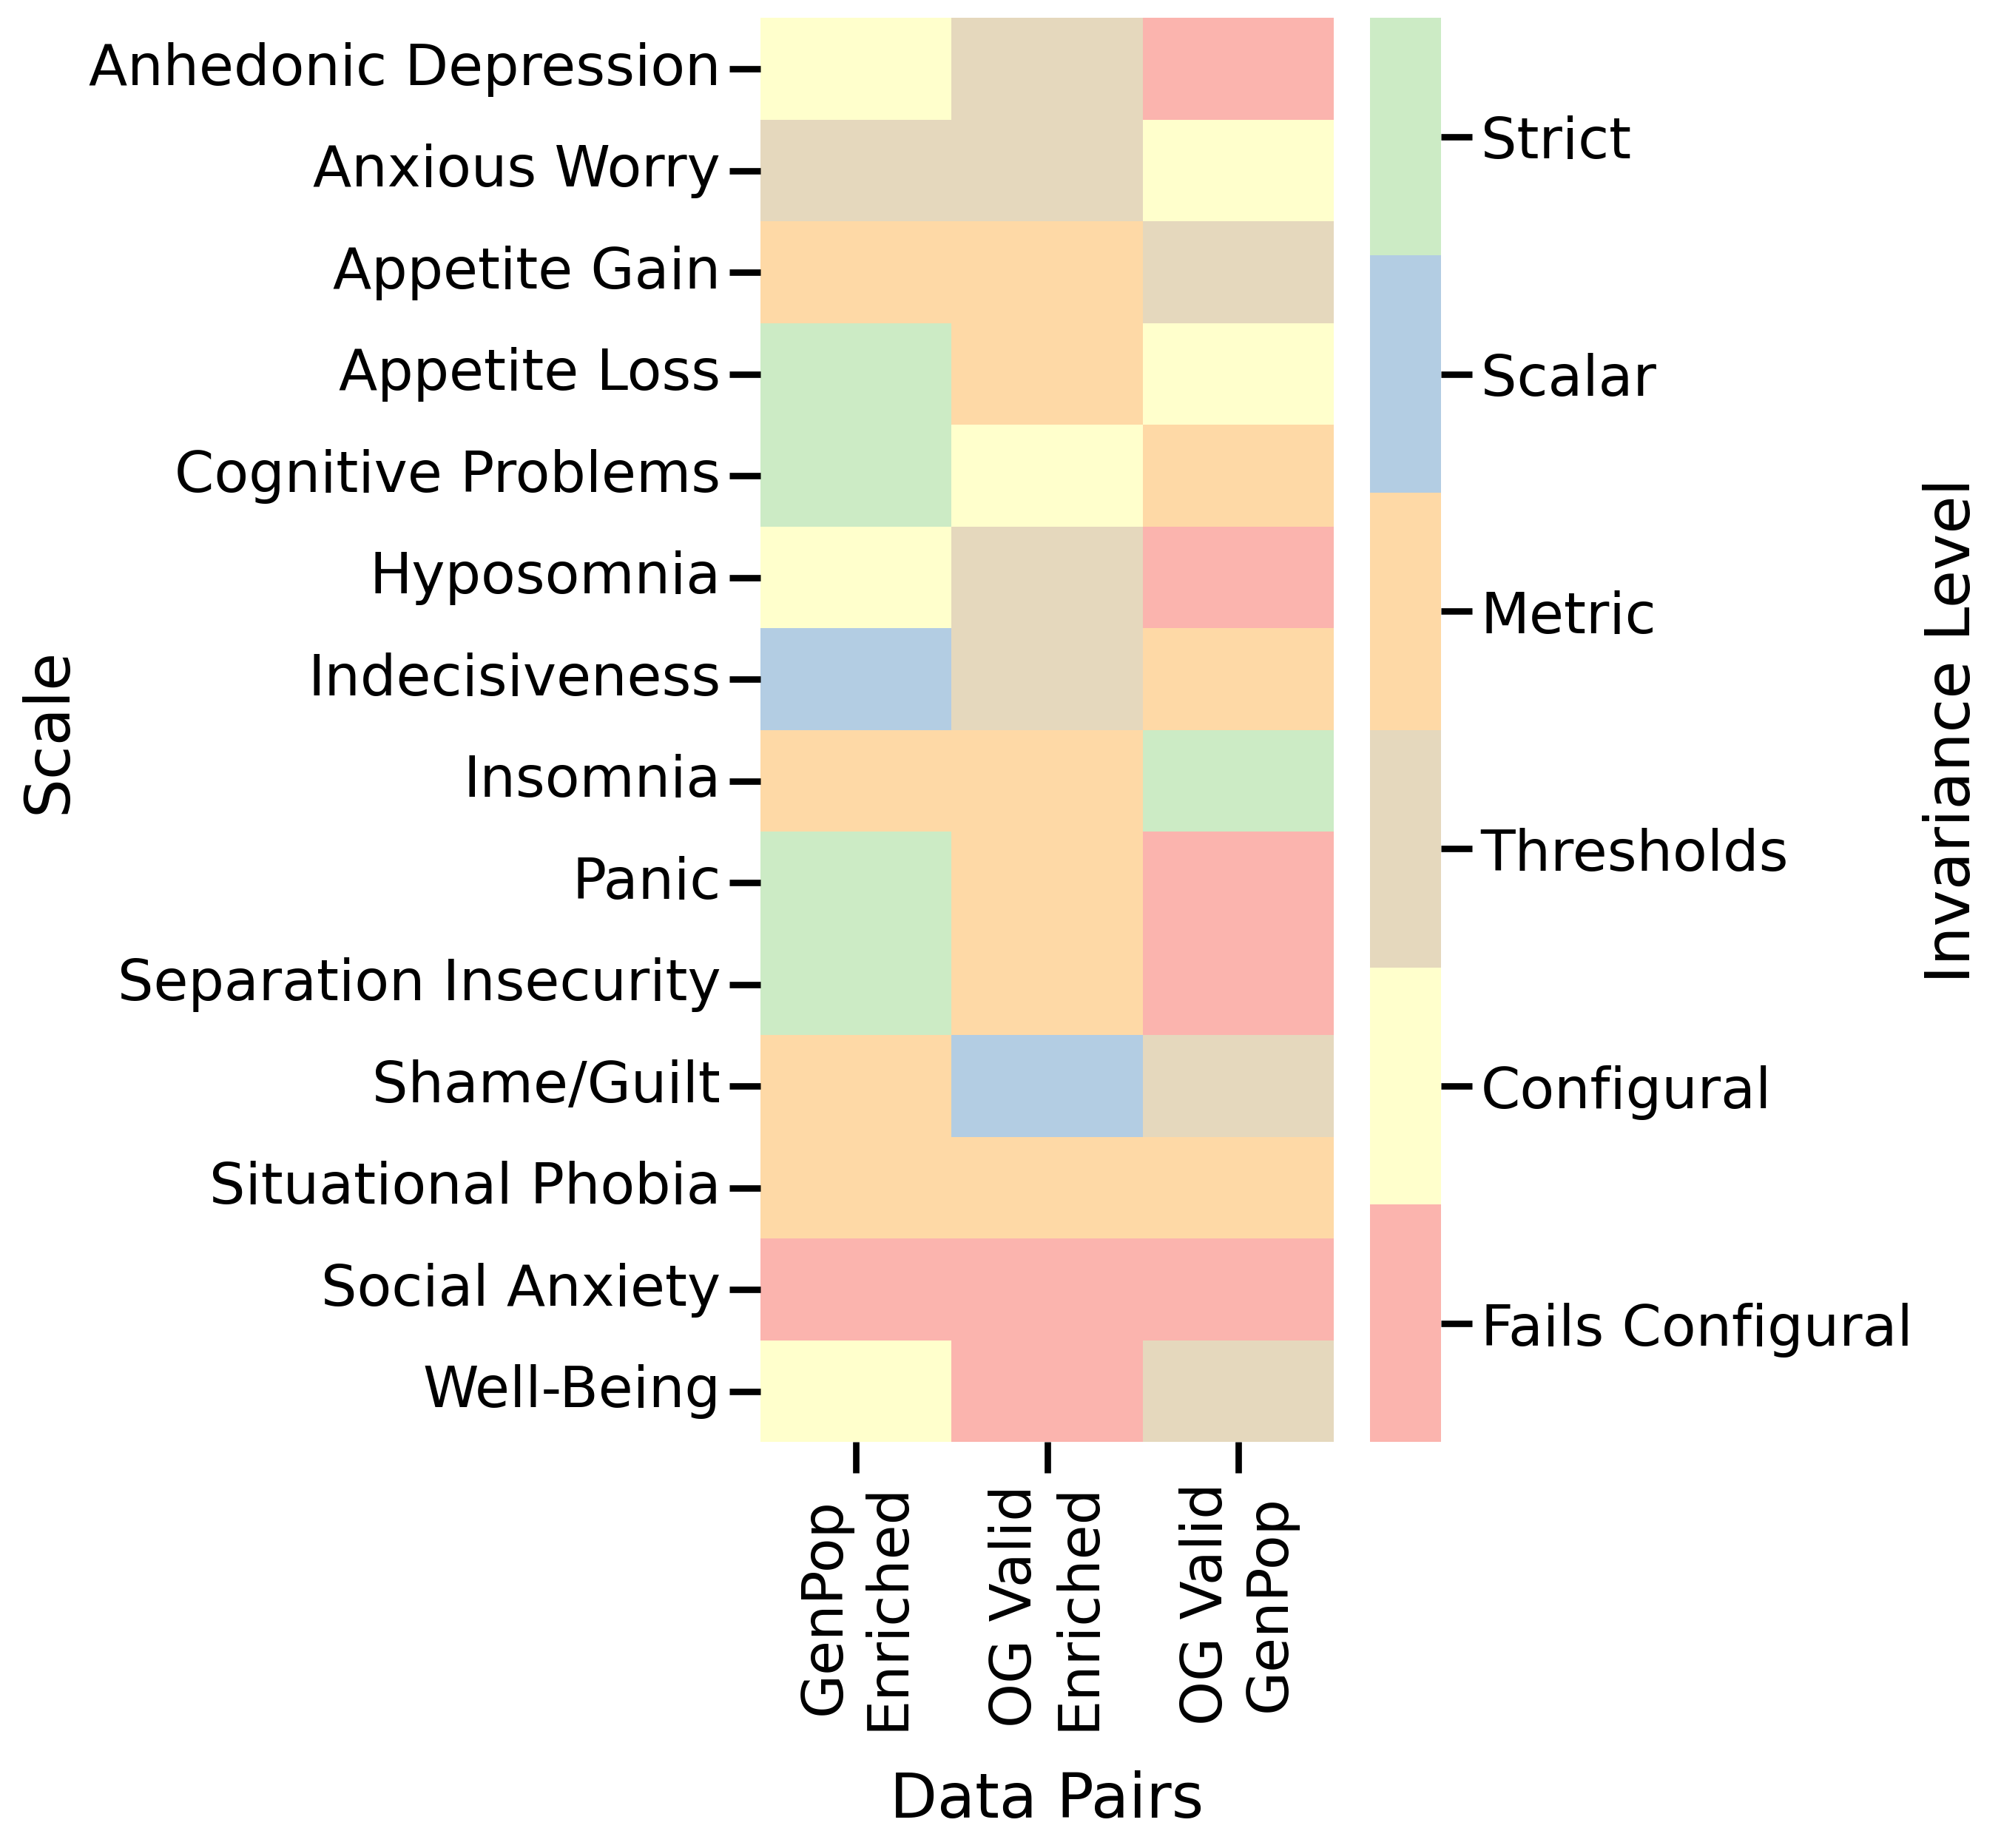

In [8]:
sns.set_context('poster')
# spread level 0..5 onto odd values 1..11 so each category sits in the
# middle of its color band
to_plot_vals = to_plot * 2 + 1
fig, ax = plt.subplots(1, figsize=(5,10), dpi=250)
sns.heatmap(to_plot_vals, cmap=colors, vmax=12, vmin=0)
colorbar = ax.collections[0].colorbar
colorbar.set_ticks([1, 3, 5, 7, 9, 11])
colorbar.set_ticklabels(['Fails Configural', 'Configural', 'Thresholds',
                         'Metric', 'Scalar', 'Strict'])
colorbar.set_label('Invariance Level')
ax.xaxis.set_label_coords(0.5, -0.23)


from pathlib import Path
Path('../figures').mkdir(exist_ok=True)
plt.gcf().savefig('../figures/invariance_ladder_heatmap.png',
                  dpi=250, bbox_inches='tight')

In [9]:
step_scalar = pd.read_pickle('../data/cfa/stepwise_scalar.pkl')

In [10]:
step_scalar

,scale,core_level,item_nos,removed_nos,items,removed,metric_item_nos,scalar_removed_nos,error
0,anhedonic_depression,metric,"[hitop77, hitop84, hitop92, hitop123, hitop182...","[hitop39, hitop93, hitop157, hitop246]",[I didn’t look forward to seeing friends or fa...,[It felt like there wasn’t anything interestin...,"[hitop77, hitop84, hitop92, hitop123, hitop182...","[hitop123, hitop84, hitop182, hitop77]",NaN
1,anxious_worry,metric,"[hitop240, hitop248, hitop265]","[hitop20, hitop34, hitop89, hitop203]","[I felt nervous and ""on edge""., I worried abou...","[I felt tense., Thoughts were racing through m...","[hitop240, hitop248, hitop265]",[hitop248],NaN
2,appetite_gain,metric,"[hitop141, hitop243, hitop275]",[hitop120],"[I thought a lot about food., I stuffed myself...",[I could not keep myself from eating.],"[hitop141, hitop243, hitop275]",[hitop141],NaN
3,appetite_loss,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,cognitive_problems,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,hyposomnia,metric,"[hitop99, hitop5, hitop66, hitop231]",[hitop181],"[I needed much less sleep than usual., I had d...",[I felt like I could keep going and going with...,"[hitop99, hitop5, hitop66, hitop231]","[hitop5, hitop231]",NaN
6,indecisiveness,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,insomnia,scalar,"[hitop160, hitop254, hitop268]",[hitop261],"[I had trouble staying asleep., I slept very p...",[I woke up early and could not get back to sle...,"[hitop160, hitop254, hitop261, hitop268]",[hitop261],NaN
8,panic,scalar,"[hitop104, hitop126, hitop215]","[hitop15, hitop211, hitop257]","[I felt nauseated., My heart was racing or pou...","[I was short of breath., I was trembling or sh...","[hitop15, hitop104, hitop126, hitop215, hitop257]","[hitop257, hitop15]",NaN
9,separation_insecurity,scalar,"[hitop40, hitop69, hitop81, hitop136, hitop151...","[hitop50, hitop113]",[I felt insecure about important relationships...,[I wanted someone else to make decisions for m...,"[hitop40, hitop69, hitop81, hitop113, hitop136...",[hitop113],NaN
